In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
project_path = "/content/drive/MyDrive/Colab Notebooks/buat skripsi"

In [ ]:
import os
os.chdir(project_path)  # pindah ke folder proyek
print("Sekarang kamu ada di:", os.getcwd())

Sekarang kamu ada di: /content/drive/MyDrive/Colab Notebooks/buat skripsi


#Preprocessing

### Load dataset

In [ ]:
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

In [ ]:
products.rename(columns={'product_name_lenght': 'product_name_length', 'product_description_lenght': 'product_description_length'}, inplace=True)

### Pre-aggregation

In [ ]:
# items → 1 order = 1 row
order_items_agg = order_items.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum'
}).reset_index()

# payments → 1 order = 1 row
payments_agg = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'mean'
}).reset_index()

# products → aggregate ke order level
product_agg = order_items.merge(products, on='product_id', how='left')

product_agg = product_agg.groupby('order_id').agg({
    'product_description_length': 'mean',
    'product_photos_qty': 'mean'
}).reset_index()

### Integrasi tabel

In [ ]:
df = orders.merge(customers, on='customer_id', how='left') \
           .merge(order_items_agg, on='order_id', how='left') \
           .merge(payments_agg, on='order_id', how='left') \
           .merge(product_agg, on='order_id', how='left') \
           .merge(reviews, on='order_id', how='left')

In [ ]:
print("Shape full:", df.shape)
print("Jumlah kolom:", len(df.columns))
df.columns.to_list()

Shape full: (99992, 24)
Jumlah kolom: 24


['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'price',
 'freight_value',
 'payment_value',
 'payment_installments',
 'product_description_length',
 'product_photos_qty',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp']

In [ ]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_value,payment_installments,product_description_length,product_photos_qty,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,38.71,1.0,268.0,4.0,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,141.46,1.0,178.0,1.0,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,179.12,3.0,232.0,1.0,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,72.20,1.0,468.0,3.0,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,28.62,1.0,316.0,4.0,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99987,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,12209,...,85.08,3.0,1517.0,1.0,e262b3f92d1ce917aa412a9406cf61a6,5.0,NaN,NaN,2017-03-22 00:00:00,2017-03-23 11:02:08
99988,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,...,195.00,3.0,828.0,4.0,29bb71b2760d0f876dfa178a76bc4734,4.0,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01
99989,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,...,271.01,5.0,500.0,2.0,371579771219f6db2d830d50805977bb,5.0,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57
99990,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,441.16,4.0,1893.0,1.0,8ab6855b9fe9b812cd03a480a25058a1,2.0,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56


### Convert datetime

In [ ]:
# 2. CONVERT DATETIME
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [ ]:
# cek tipe data
df.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]
customer_unique_id,object
customer_zip_code_prefix,int64


In [ ]:
df['customer_zip_code_prefix'] = df['customer_zip_code_prefix'].astype(str)

print(df[['customer_zip_code_prefix']].dtypes)

customer_zip_code_prefix    object
dtype: object


In [ ]:
df.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]
customer_unique_id,object
customer_zip_code_prefix,object


cek duplikat

In [ ]:
duplicate_counts_per_column = {}
for col in df.columns:
    duplicate_counts_per_column[col] = df[col].duplicated().sum()

df_duplicates_per_column = pd.DataFrame(
    list(duplicate_counts_per_column.items()),
    columns=['Column', 'Duplicate_Count']
)
display(df_duplicates_per_column)

,Column,Duplicate_Count
0,order_id,551
1,customer_id,551
2,order_status,99984
3,order_purchase_timestamp,1117
4,order_approved_at,9258
5,order_delivered_carrier_date,18973
6,order_delivered_customer_date,4327
7,order_estimated_delivery_date,99533
8,customer_unique_id,3896
9,customer_zip_code_prefix,84998


### cek missing value

In [ ]:
# missing value
print(df.isnull().sum().sort_values(ascending=False))

review_comment_title             88424
review_comment_message           59015
order_delivered_customer_date     2987
product_photos_qty                2176
product_description_length        2176
order_delivered_carrier_date      1793
price                              778
freight_value                      778
review_creation_date               768
review_answer_timestamp            768
review_id                          768
review_score                       768
order_approved_at                  161
payment_value                        1
payment_installments                 1
order_id                             0
order_estimated_delivery_date        0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
customer_unique_id                   0
customer_zip_code_prefix             0
customer_city                        0
customer_state                       0
dtype: int64


In [ ]:
df.to_csv('df_full_cust.csv', index=False)

In [ ]:
df_clean = df.copy()

### Handling missing value

In [ ]:
# review (optional input → kosong)
df_clean['review_comment_message'] = df_clean['review_comment_message'].fillna('')

# drop review kosong
df_clean = df_clean[df_clean['review_score'].notna()]

# numerik transaksi
num_trans_cols = ['price','freight_value','payment_value']
for col in num_trans_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# product attributes
product_cols = ['product_description_length','product_photos_qty']
for col in product_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# installments (default)
df_clean['payment_installments'] = df_clean['payment_installments'].fillna(1)

In [ ]:
num_cols = df_clean.select_dtypes(include=np.number).columns

print("Kolom numerik:", num_cols)

Kolom numerik: Index(['price', 'freight_value', 'payment_value', 'payment_installments',
       'product_description_length', 'product_photos_qty', 'review_score'],
      dtype='object')


In [ ]:
num_cols = [
    'freight_value',
    'payment_value',
    'payment_installments',
    'product_description_length',
    'product_photos_qty',
]

Distribution plot

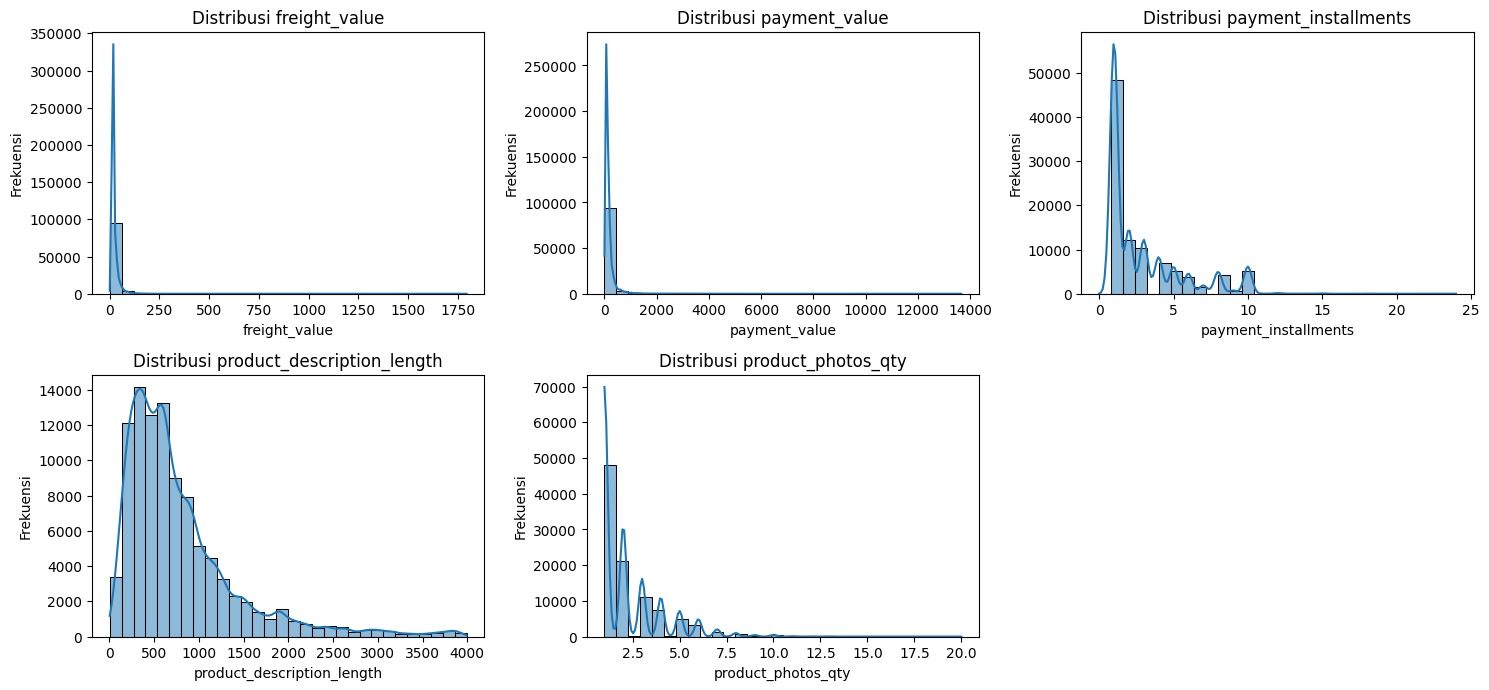

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(
        df_clean[col],
        bins=30,
        kde=True
    )
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

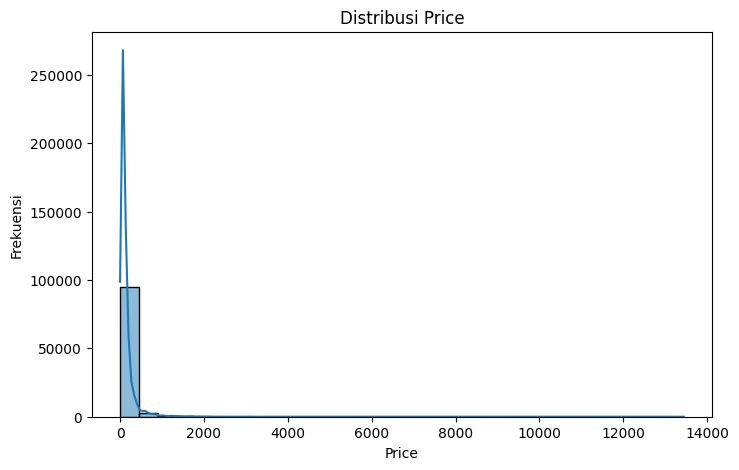

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean['price'],
    bins=30,
    kde=True
)

plt.title('Distribusi Price')
plt.xlabel('Price')
plt.ylabel('Frekuensi')

plt.show()

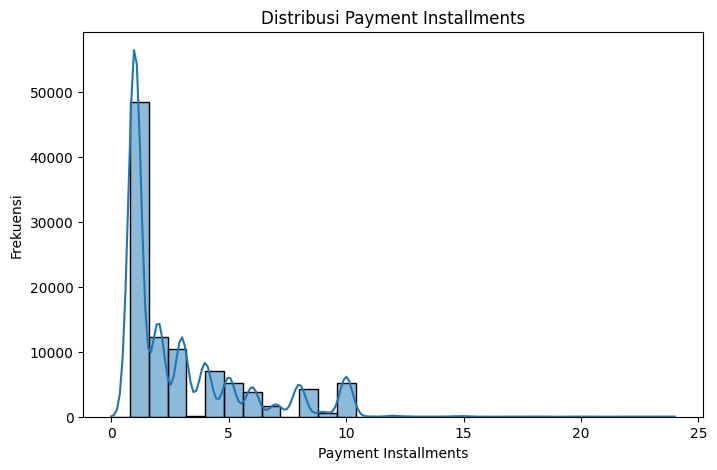

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean['payment_installments'],
    bins=30,
    kde=True
)

plt.title('Distribusi Payment Installments')
plt.xlabel('Payment Installments')
plt.ylabel('Frekuensi')

plt.show()

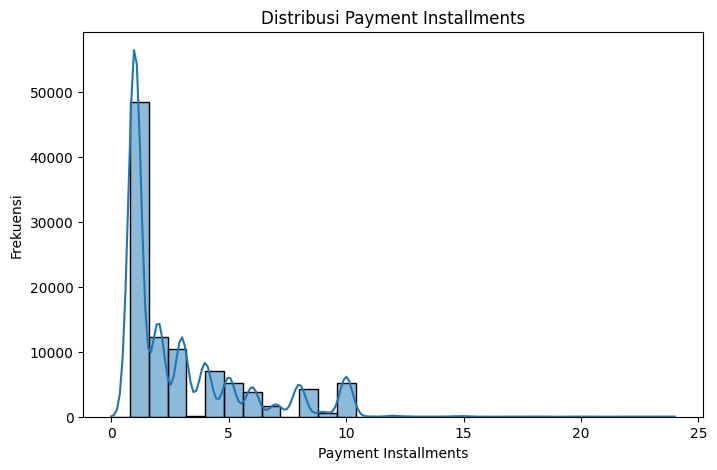

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean['payment_installments'],
    bins=30,
    kde=True
)

plt.title('Distribusi Payment Installments')
plt.xlabel('Payment Installments')
plt.ylabel('Frekuensi')

plt.show()

### Outlier checking

In [ ]:
def outlier_count(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = series[(series < lower) | (series > upper)]
    return len(outliers)

print("=== OUTLIER COUNT ===")
for col in num_cols:
    print(f"{col}: {outlier_count(df_clean[col])}")

=== OUTLIER COUNT ===
freight_value: 10145
payment_value: 7838
payment_installments: 6169
product_description_length: 6230
product_photos_qty: 2831


In [ ]:
num_cols = [
    'freight_value',
    'payment_value',
]

def outlier_percentage(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = series[(series < lower) | (series > upper)]
    return len(outliers) / len(series) * 100

print("=== OUTLIER CHECK ===")
for col in num_cols:
    print(f"{col}: {outlier_percentage(df_clean[col]):.2f}%")

=== OUTLIER CHECK ===
freight_value: 10.22%
payment_value: 7.90%


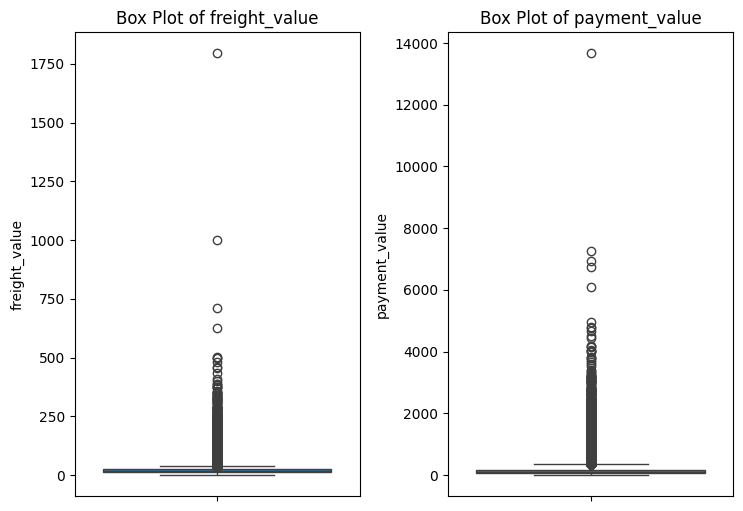

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 4, i + 1)  # Adjust subplot grid as needed
    sns.boxplot(y=df_clean[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

### Outlier handling

In [ ]:
def winsorize(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

# hanya kolom relevan
cols_to_handle = ['payment_value','freight_value']

for col in cols_to_handle:
    df_clean[col] = winsorize(df_clean[col])

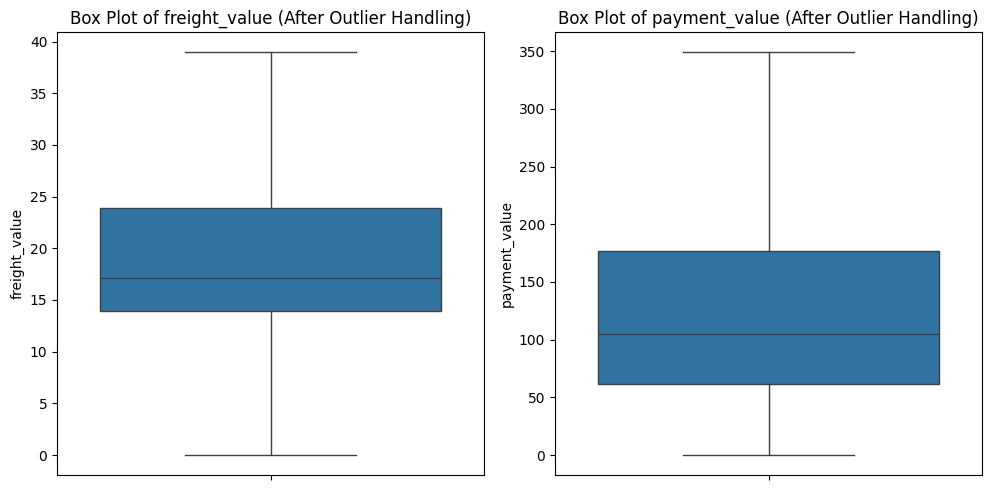

In [ ]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df_clean[col])
    plt.title(f'Box Plot of {col} (After Outlier Handling)')
plt.tight_layout()
plt.show()

# Pembentukan dataset RFM

In [ ]:
df_rfm = df_clean[df_clean['order_status'] == 'delivered'].copy()

In [ ]:
# RFM Calculations
reference_date = df_rfm["order_purchase_timestamp"].max()

# recency
recency = df_rfm.groupby("customer_unique_id")["order_purchase_timestamp"] \
    .apply(lambda x: (reference_date - x.max()).days)

# frequency
frequency = df_rfm.groupby("customer_unique_id")["order_id"].nunique()

# monetary
monetary = df_rfm.groupby("customer_unique_id")["payment_value"].sum()

rfm = pd.concat([recency, frequency, monetary], axis=1)
rfm.columns = ['recency','frequency','monetary']

In [ ]:
rfm.head(10)

,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.900
0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.190
0000f46a3911fa3c0805444483337064,536,1,86.220
0000f6ccb0745a6a4b88665a16c9f078,320,1,43.620
0004aac84e0df4da2b147fca70cf8255,287,1,196.890
0004bd2a26a76fe21f786e4fbd80607f,145,1,166.980
00050ab1314c0e55a6ca13cf7181fecf,131,1,35.380
00053a61a98854899e70ed204dd4bafe,182,1,348.955
0005e1862207bf6ccc02e4228effd9a0,542,1,150.120


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=rfm.head(10))

https://docs.google.com/spreadsheets/d/1hgfCUl9CZn_MFOLHYtdEaj70aZz4qPjvJrrZcu4avaQ/edit#gid=0


In [ ]:
rfm.shape

(92755, 3)

In [ ]:
rfm.describe()

,recency,frequency,monetary
count,92755.000000,92755.000000,92755.000000
mean,236.795041,1.033173,138.420210
std,152.600235,0.208415,101.808114
min,0.000000,1.000000,9.590000
25%,113.000000,1.000000,63.090000
50%,218.000000,1.000000,107.820000
75%,345.000000,1.000000,182.910000
max,713.000000,15.000000,1395.820000


In [ ]:
rfm

,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.900
0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.190
0000f46a3911fa3c0805444483337064,536,1,86.220
0000f6ccb0745a6a4b88665a16c9f078,320,1,43.620
0004aac84e0df4da2b147fca70cf8255,287,1,196.890
...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,446,1,348.955
fffea47cd6d3cc0a88bd621562a9d061,261,1,84.580
ffff371b4d645b6ecea244b27531430a,567,1,112.460


In [ ]:
# Normalization
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency','frequency','monetary']])

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['recency','frequency','monetary'],
    index=rfm.index
)

In [ ]:
rfm_scaled_df.head(10)

,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,-0.824348,-0.159171,0.034180
0000b849f77a49e4a4ce2b2a4ca5be3f,-0.804689,-0.159171,-1.092553
0000f46a3911fa3c0805444483337064,1.960722,-0.159171,-0.512734
0000f6ccb0745a6a4b88665a16c9f078,0.545251,-0.159171,-0.931171
0004aac84e0df4da2b147fca70cf8255,0.328998,-0.159171,0.574317
0004bd2a26a76fe21f786e4fbd80607f,-0.601543,-0.159171,0.280527
00050ab1314c0e55a6ca13cf7181fecf,-0.693286,-0.159171,-1.012108
00053a61a98854899e70ed204dd4bafe,-0.359078,-0.159171,2.067968
0005e1862207bf6ccc02e4228effd9a0,2.000040,-0.159171,0.114921


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=rfm_scaled_df.head(5))

https://docs.google.com/spreadsheets/d/1zvc5oGziwiwNumSxB29yOOubEipYrcvl8UJw5O1oORo/edit#gid=0


# K-Means Clustering

In [ ]:
rfm_scaled_df = rfm_scaled_df.reset_index()

Mencari nilai k yang optimal dengan silhouette score dan davies-bouldin index

In [ ]:
silhouette_scores = {}
dbi_scores = {}

K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled_df[['recency', 'frequency', 'monetary']])

    silhouette_scores[k] = silhouette_score(rfm_scaled_df[['recency', 'frequency', 'monetary']], labels)
    dbi_scores[k] = davies_bouldin_score(rfm_scaled_df[['recency', 'frequency', 'monetary']], labels)


print("\nSilhouette Scores:")
print(silhouette_scores)

print("\nDavies-Bouldin Index:")
print(dbi_scores)


Silhouette Scores:
{2: np.float64(0.7125414712348405), 3: np.float64(0.3746232609602548), 4: np.float64(0.4384890990829238), 5: np.float64(0.37511394637201884), 6: np.float64(0.38576077590654617), 7: np.float64(0.38782164120048557), 8: np.float64(0.3910768185532325), 9: np.float64(0.38812412684960634)}

Davies-Bouldin Index:
{2: np.float64(0.6163165097855106), 3: np.float64(0.9312726038766694), 4: np.float64(0.7304704985024532), 5: np.float64(0.8159419611476164), 6: np.float64(0.8330688927836674), 7: np.float64(0.8780940237345266), 8: np.float64(0.8129817509265664), 9: np.float64(0.8365684527133692)}


Clustering

In [ ]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm_scaled_df["cluster"] = kmeans.fit_predict(rfm_scaled_df[['recency', 'frequency', 'monetary']])

In [ ]:
rfm_scaled_df.head(10)

,customer_unique_id,recency,frequency,monetary,cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,-0.824348,-0.159171,0.034180,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,-0.804689,-0.159171,-1.092553,1
2,0000f46a3911fa3c0805444483337064,1.960722,-0.159171,-0.512734,2
3,0000f6ccb0745a6a4b88665a16c9f078,0.545251,-0.159171,-0.931171,2
4,0004aac84e0df4da2b147fca70cf8255,0.328998,-0.159171,0.574317,0
5,0004bd2a26a76fe21f786e4fbd80607f,-0.601543,-0.159171,0.280527,1
6,00050ab1314c0e55a6ca13cf7181fecf,-0.693286,-0.159171,-1.012108,1
7,00053a61a98854899e70ed204dd4bafe,-0.359078,-0.159171,2.067968,0
8,0005e1862207bf6ccc02e4228effd9a0,2.000040,-0.159171,0.114921,2
9,0005ef4cd20d2893f0d9fbd94d3c0d97,-0.444268,-0.159171,-0.085065,1


In [ ]:
# Merge original RFM data with cluster assignments
rfm_with_clusters = rfm.merge(rfm_scaled_df[['customer_unique_id', 'cluster']], on='customer_unique_id', how='left')

# Calculate the mean of RFM metrics for each cluster
cluster_rfm_description = rfm_with_clusters.groupby('cluster')[['recency', 'frequency', 'monetary']].mean()

display(cluster_rfm_description)

print("\nNumber of customers in each cluster:")
display(rfm_with_clusters['cluster'].value_counts().sort_index())

,recency,frequency,monetary
cluster,,,
0,228.729555,1.000000,299.726917
1,126.553382,1.000000,96.077634
2,392.947882,1.000000,97.824491
3,219.441751,2.113242,290.989740



Number of customers in each cluster:


,count
cluster,
0,16373
1,42477
2,31141
3,2764


Clustering visualization dengan PCA

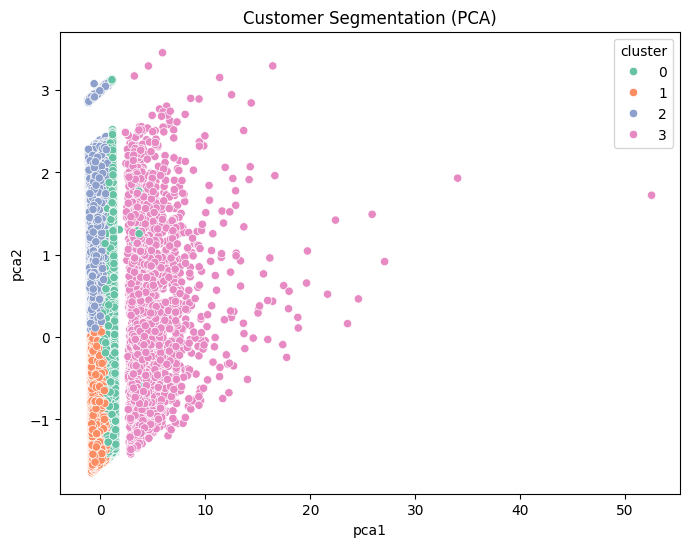

In [ ]:
# PCA 2 komponen
pca = PCA(n_components=2)

# Apply PCA on the scaled numerical features
rfm_pca = pca.fit_transform(rfm_scaled_df[['recency','frequency','monetary']])

# Create a new DataFrame for plotting that contains customer_unique_id, pca components and cluster
rfm_plot_df = pd.DataFrame({
    'customer_unique_id': rfm_scaled_df['customer_unique_id'],
    'pca1': rfm_pca[:,0],
    'pca2': rfm_pca[:,1],
    'cluster': rfm_scaled_df['cluster']
})

# plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='pca1',
    y='pca2',
    hue='cluster',
    data=rfm_plot_df, # Use the new dataframe for plotting
    palette='Set2'
)

plt.title('Customer Segmentation (PCA)')
plt.show()

In [ ]:
print(pca.explained_variance_ratio_)
print("Total variance:", sum(pca.explained_variance_ratio_))

[0.4279556  0.33274842]
Total variance: 0.7607040237903736


In [ ]:
# Save clusters to CSV
rfm_scaled_df[['cluster']].reset_index().to_csv('customer_clusters.csv', index=False)
print('Saved: customer_clusters.csv')

Saved: customer_clusters.csv


#Pembentukan dataset untuk Causal Discovery

In [ ]:
df_causal = df_clean.copy()

1. feature construction (order-level)

In [ ]:
# cancellation
df_causal["cancellation"] = (df_causal["order_status"] == "canceled").astype(int)

# delivery_time
df_causal["delivery_time"] = (
    df_causal["order_delivered_customer_date"] -
    df_causal["order_purchase_timestamp"]
).dt.days

# delivery_delay
df_causal["delivery_delay"] = (
    df_causal["order_delivered_customer_date"] -
    df_causal["order_estimated_delivery_date"]
).dt.days

# no_delivery
df_causal["no_delivery"] = df_causal["delivery_delay"].isna().astype(int)

# late delivery
df_causal["late_delivery_flag"] = (df_causal["delivery_delay"] > 0).astype(int)

2. agregasi ke customer-level

In [ ]:
causal = df_causal.groupby("customer_unique_id").agg({
    "cancellation":"mean",
    "no_delivery":"mean",

    "delivery_delay":"mean",
    "delivery_time":"mean",
    "late_delivery_flag":"mean",

    "payment_installments":"mean",
    "payment_value":"sum",
    "freight_value":"sum",

    "product_description_length":"mean",
    "product_photos_qty":"mean",

    "review_score":"mean"
}).reset_index()

In [ ]:
causal.rename(columns={
    "payment_installments":"avg_installments",
    "payment_value":"total_payment"
}, inplace=True)

In [ ]:
print(causal.isnull().sum().sort_values(ascending=False))

delivery_delay                2627
delivery_time                 2627
cancellation                     0
customer_unique_id               0
no_delivery                      0
late_delivery_flag               0
avg_installments                 0
total_payment                    0
freight_value                    0
product_description_length       0
product_photos_qty               0
review_score                     0
dtype: int64


3. handling missing value (contextual)

In [ ]:
causal['delivery_delay'] = causal['delivery_delay'].fillna(0)
causal['delivery_time'] = causal['delivery_time'].fillna(0)

4. buat variabel outcome

In [ ]:
causal["is_dissatisfied"] = (causal["review_score"] < 3).astype(int)
causal = causal.drop(columns=["review_score"])

In [ ]:
# missing value
print(causal.isnull().sum().sort_values(ascending=False))

customer_unique_id            0
cancellation                  0
no_delivery                   0
delivery_delay                0
delivery_time                 0
late_delivery_flag            0
avg_installments              0
total_payment                 0
freight_value                 0
product_description_length    0
product_photos_qty            0
is_dissatisfied               0
dtype: int64


In [ ]:
causal

,customer_unique_id,cancellation,no_delivery,delivery_delay,delivery_time,late_delivery_flag,avg_installments,total_payment,freight_value,product_description_length,product_photos_qty,is_dissatisfied
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,-5.0,6.0,0.0,8.0,141.900,12.00,236.0,1.0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,-5.0,3.0,0.0,1.0,27.190,8.29,635.0,1.0,0
2,0000f46a3911fa3c0805444483337064,0.0,0.0,-2.0,25.0,0.0,8.0,86.220,17.22,177.0,3.0,0
3,0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,-12.0,20.0,0.0,4.0,43.620,17.63,1741.0,5.0,0
4,0004aac84e0df4da2b147fca70cf8255,0.0,0.0,-8.0,13.0,0.0,6.0,196.890,16.89,794.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
95375,fffcf5a5ff07b0908bd4e2dbc735a684,0.0,0.0,-27.0,27.0,0.0,10.0,348.955,38.94,478.5,1.0,0
95376,fffea47cd6d3cc0a88bd621562a9d061,0.0,0.0,-3.0,30.0,0.0,1.0,84.580,19.69,506.0,2.0,0
95377,ffff371b4d645b6ecea244b27531430a,0.0,0.0,-30.0,14.0,0.0,1.0,112.460,22.56,716.0,5.0,0
95378,ffff5962728ec6157033ef9805bacc48,0.0,0.0,-14.0,11.0,0.0,5.0,133.690,18.69,591.0,3.0,0


In [ ]:
causal.shape

(95380, 12)

In [ ]:
causal['is_dissatisfied'].value_counts()

,count
is_dissatisfied,
0,81415
1,13965


In [ ]:
pd.crosstab(
    causal["order_status"],
    causal["no_delivery"]
)

save dataset untuk causal discovery di tetrad

In [ ]:
# drop id sebelum tetrad
causal_tetrad = causal.drop(
    columns=["customer_unique_id"]
)

causal_tetrad.to_csv(
    "CustomerCausal_dataset.csv",
    index=False
)

print("Saved: CustomerCausal_dataset.csv")

Saved: CustomerCausal_dataset.csv


In [ ]:
causal_tetrad.shape

(95380, 11)

In [ ]:
causal_tetrad

,cancellation,no_delivery,delivery_delay,delivery_time,late_delivery_flag,avg_installments,total_payment,freight_value,product_description_length,product_photos_qty,is_dissatisfied
0,0.0,0.0,-5.0,6.0,0.0,8.0,141.900,12.00,236.0,1.0,0
1,0.0,0.0,-5.0,3.0,0.0,1.0,27.190,8.29,635.0,1.0,0
2,0.0,0.0,-2.0,25.0,0.0,8.0,86.220,17.22,177.0,3.0,0
3,0.0,0.0,-12.0,20.0,0.0,4.0,43.620,17.63,1741.0,5.0,0
4,0.0,0.0,-8.0,13.0,0.0,6.0,196.890,16.89,794.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...
95375,0.0,0.0,-27.0,27.0,0.0,10.0,348.955,38.94,478.5,1.0,0
95376,0.0,0.0,-3.0,30.0,0.0,1.0,84.580,19.69,506.0,2.0,0
95377,0.0,0.0,-30.0,14.0,0.0,1.0,112.460,22.56,716.0,5.0,0
95378,0.0,0.0,-14.0,11.0,0.0,5.0,133.690,18.69,591.0,3.0,0


In [ ]:
causal_tetrad.columns.tolist()

['cancellation',
 'no_delivery',
 'delivery_delay',
 'delivery_time',
 'late_delivery_flag',
 'avg_installments',
 'total_payment',
 'freight_value',
 'product_description_length',
 'product_photos_qty',
 'is_dissatisfied']

#Join dataset cluster + causal discovery

In [ ]:
clusters = rfm_scaled_df[
    ['customer_unique_id', 'cluster']
].copy()

# Restore 'customer_unique_id' to causal DataFrame as it was dropped previously.
# Assuming the order of rows in 'causal' corresponds to the sorted unique customer_unique_id from df_causal.
causal['customer_unique_id'] = sorted(df_causal['customer_unique_id'].unique())

# samakan tipe data
causal['customer_unique_id'] = (
    causal['customer_unique_id']
    .astype(str)
)

clusters['customer_unique_id'] = (
    clusters['customer_unique_id']
    .astype(str)
)

# join
causal_joined = causal.merge(
    clusters,
    on='customer_unique_id',
    how='inner'
)

print(causal_joined.shape)

(92755, 13)


In [ ]:
causal_joined

,customer_unique_id,cancellation,no_delivery,delivery_delay,delivery_time,late_delivery_flag,avg_installments,total_payment,freight_value,product_description_length,product_photos_qty,is_dissatisfied,cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,-5.0,6.0,0.0,8.0,141.900,12.00,236.0,1.0,0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,-5.0,3.0,0.0,1.0,27.190,8.29,635.0,1.0,0,1
2,0000f46a3911fa3c0805444483337064,0.0,0.0,-2.0,25.0,0.0,8.0,86.220,17.22,177.0,3.0,0,2
3,0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,-12.0,20.0,0.0,4.0,43.620,17.63,1741.0,5.0,0,2
4,0004aac84e0df4da2b147fca70cf8255,0.0,0.0,-8.0,13.0,0.0,6.0,196.890,16.89,794.0,3.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
92750,fffcf5a5ff07b0908bd4e2dbc735a684,0.0,0.0,-27.0,27.0,0.0,10.0,348.955,38.94,478.5,1.0,0,0
92751,fffea47cd6d3cc0a88bd621562a9d061,0.0,0.0,-3.0,30.0,0.0,1.0,84.580,19.69,506.0,2.0,0,2
92752,ffff371b4d645b6ecea244b27531430a,0.0,0.0,-30.0,14.0,0.0,1.0,112.460,22.56,716.0,5.0,0,2
92753,ffff5962728ec6157033ef9805bacc48,0.0,0.0,-14.0,11.0,0.0,5.0,133.690,18.69,591.0,3.0,0,1


In [ ]:
causal_joined['is_dissatisfied'].value_counts()

,count
is_dissatisfied,
0,80871
1,11884


In [ ]:
causal.to_csv("ClusterCausalJoined_dataset.csv", index=False)
print("Saved: ClusterCausalJoined_dataset.csv")

Saved: ClusterCausalJoined_dataset.csv


#Memisahkan Dataset berdasarkan Cluster

In [ ]:
# Dapatkan daftar unik cluster
unique_clusters = causal_joined['cluster'].unique()

# Buat dictionary untuk menyimpan DataFrame per cluster
causal_clusters = {}

# Iterasi dan pisahkan dataset
for cluster_id in unique_clusters:
    causal_clusters[cluster_id] = causal_joined[causal_joined['cluster'] == cluster_id].copy()
    print(f"Cluster {cluster_id} shape: {causal_clusters[cluster_id].shape}")
    print(f"Head of Cluster {cluster_id}:")
    display(causal_clusters[cluster_id].head())
    print("\n")

Cluster 1 shape: (42477, 13)
Head of Cluster 1:


,customer_unique_id,cancellation,no_delivery,delivery_delay,delivery_time,late_delivery_flag,avg_installments,total_payment,freight_value,product_description_length,product_photos_qty,is_dissatisfied,cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,-5.0,6.0,0.0,8.0,141.90,12.00,236.0,1.0,0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,-5.0,3.0,0.0,1.0,27.19,8.29,635.0,1.0,0,1
5,0004bd2a26a76fe21f786e4fbd80607f,0.0,0.0,-12.0,1.0,0.0,8.0,166.98,12.98,360.0,3.0,0,1
6,00050ab1314c0e55a6ca13cf7181fecf,0.0,0.0,-12.0,6.0,0.0,1.0,35.38,7.39,818.0,6.0,0,1
9,0005ef4cd20d2893f0d9fbd94d3c0d97,0.0,0.0,31.0,53.0,1.0,4.0,129.76,24.86,1023.0,1.0,1,1




Cluster 2 shape: (31141, 13)
Head of Cluster 2:


,customer_unique_id,cancellation,no_delivery,delivery_delay,delivery_time,late_delivery_flag,avg_installments,total_payment,freight_value,product_description_length,product_photos_qty,is_dissatisfied,cluster
2,0000f46a3911fa3c0805444483337064,0.0,0.0,-2.0,25.0,0.0,8.0,86.22,17.22,177.0,3.0,0,2
3,0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,-12.0,20.0,0.0,4.0,43.62,17.63,1741.0,5.0,0,2
8,0005e1862207bf6ccc02e4228effd9a0,0.0,0.0,-28.0,4.0,0.0,3.0,150.12,15.12,1118.0,6.0,0,2
10,0006fdc98a402fceb4eb0ee528f6a8d4,0.0,0.0,-12.0,16.0,0.0,2.0,29.00,15.10,116.0,1.0,0,2
11,00082cbe03e478190aadbea78542e933,0.0,0.0,-8.0,10.0,0.0,1.0,126.26,38.94,472.0,4.0,0,2




Cluster 0 shape: (16373, 13)
Head of Cluster 0:


,customer_unique_id,cancellation,no_delivery,delivery_delay,delivery_time,late_delivery_flag,avg_installments,total_payment,freight_value,product_description_length,product_photos_qty,is_dissatisfied,cluster
4,0004aac84e0df4da2b147fca70cf8255,0.0,0.0,-8.0,13.0,0.0,6.0,196.890,16.89,794.0,3.0,0,0
7,00053a61a98854899e70ed204dd4bafe,0.0,0.0,-10.0,16.0,0.0,3.0,348.955,37.18,190.0,1.0,1,0
18,000de6019bb59f34c099a907c151d855,0.0,0.0,-16.0,4.0,0.0,4.0,257.440,27.64,177.5,1.0,1,0
22,000fbf0473c10fc1ab6f8d2d286ce20c,0.0,0.0,-14.0,8.0,0.0,1.0,348.955,38.94,347.0,1.0,0,0
23,0010a452c6d13139e50b57f19f52e04e,0.0,0.0,-19.0,14.0,0.0,10.0,325.930,26.93,744.0,1.0,1,0




Cluster 3 shape: (2764, 13)
Head of Cluster 3:


,customer_unique_id,cancellation,no_delivery,delivery_delay,delivery_time,late_delivery_flag,avg_installments,total_payment,freight_value,product_description_length,product_photos_qty,is_dissatisfied,cluster
104,004288347e5e88a27ded2bb23747066c,0.0,0.0,-17.5,6.5,0.0,2.0,354.37,36.48,631.5,1.0,0,3
243,00a39521eb40f7012db50455bf083460,0.0,0.0,-19.0,17.5,0.0,1.0,123.25,41.80,1022.0,1.0,0,3
304,00cc12a6d8b578b8ebd21ea4e2ae8b27,0.0,0.0,-12.5,5.5,0.0,1.0,252.40,52.80,459.5,1.5,0,3
402,011575986092c30523ecb71ff10cb473,0.0,0.0,-10.0,13.0,0.0,1.5,214.90,32.00,593.0,6.5,0,3
417,011b4adcd54683b480c4d841250a987f,0.0,0.0,-16.0,12.5,0.0,8.0,236.30,52.87,2267.5,3.0,0,3


In [ ]:
for cluster_id, df in causal_clusters.items():
    df = df.drop(columns=['customer_unique_id', 'cluster'])
    filename = f"causal_cluster_{cluster_id}.csv"
    df.to_csv(filename, index=False)
    print(f"Saved: {filename}")

Saved: causal_cluster_1.csv
Saved: causal_cluster_2.csv
Saved: causal_cluster_0.csv
Saved: causal_cluster_3.csv


In [ ]:
is_dissatisfied_counts = {}

for cluster_id, df in causal_clusters.items():
    is_dissatisfied_counts[cluster_id] = df['is_dissatisfied'].value_counts()
    print(f"Cluster {cluster_id}:")
    print(is_dissatisfied_counts[cluster_id])

Cluster 1:
is_dissatisfied
0    37237
1     5240
Name: count, dtype: int64
Cluster 2:
is_dissatisfied
0    27594
1     3547
Name: count, dtype: int64
Cluster 0:
is_dissatisfied
0    13561
1     2812
Name: count, dtype: int64
Cluster 3:
is_dissatisfied
0    2479
1     285
Name: count, dtype: int64
